<img src="http://hilpisch.com/tpq_logo.png" width=350px align="right">

# Certificate Programs

**Mentoring Session**

## Simple Neural Networks in Python

The Python Quants GmbH

In [ ]:
!git clone https://github.com/tpq-classes/python_for_algo_trading_addon.git
import sys
sys.path.append('python_for_algo_trading_addon')


In [1]:
import numpy as np
from pylab import plt
plt.style.use('seaborn-v0_8')
%matplotlib inline

## Neural Network for Regression

[Regression & Neural Networks](https://www.cs.cmu.edu/afs/cs.cmu.edu/academic/class/15381-s06/www/nn.pdf)

### Linear OLS Regression

In [2]:
np.random.seed(100)
x = np.linspace(0, 10, 5)
y = 3 * x + 2.5 + np.random.standard_normal(len(x)) * 1.5

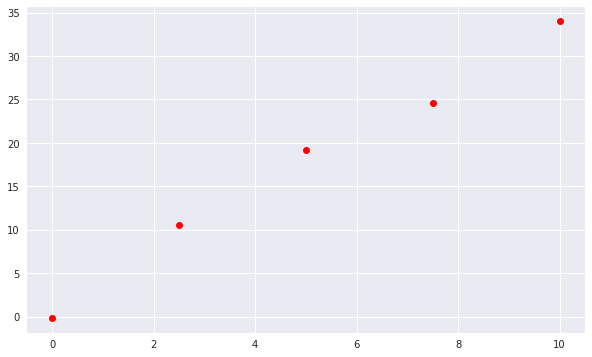

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(x, y, 'ro');

In [4]:
reg = np.polyfit(x, y, deg=1)

In [5]:
reg

array([3.29202336, 1.18233382])

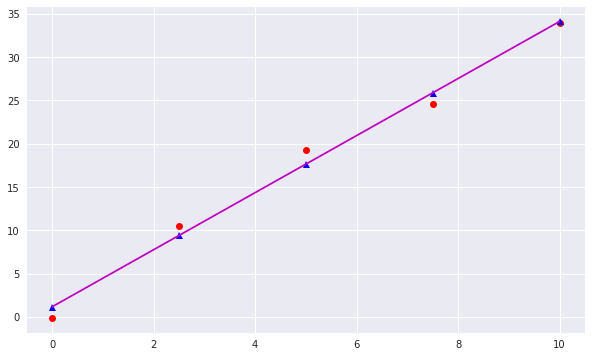

In [6]:
plt.figure(figsize=(10, 6))
yr = np.polyval(reg, x)
plt.plot(x, y, 'ro')
plt.plot(x, yr, 'b^')
plt.plot(x, yr, 'm');

In [7]:
((y - yr) ** 2).mean()

1.4046290257369272

### Network Training &mdash; Single Step

In [8]:
l0 = np.array((x, len(x) * [1])).T

In [9]:
l0

array([[ 0. ,  1. ],
       [ 2.5,  1. ],
       [ 5. ,  1. ],
       [ 7.5,  1. ],
       [10. ,  1. ]])

In [10]:
weights = np.array((2., 2.))

In [11]:
def act(x):  # activation function
    return x
def act_deriv(x):  # first derivative of activation function
    return 1

In [12]:
l1 = act(np.dot(l0, weights))
l1

array([ 2.,  7., 12., 17., 22.])

In [13]:
l1 = np.dot(l0, weights)
l1

array([ 2.,  7., 12., 17., 22.])

In [14]:
y

array([-0.12464821, 10.5140206 , 19.2295537 , 24.62134595, 33.97198118])

In [15]:
d = y - l1
d

array([-2.12464821,  3.5140206 ,  7.2295537 ,  7.62134595, 11.97198118])

In [16]:
(d ** 2).mean()  # MSE

54.10843299695061

In [17]:
alpha = 0.01  # learning rate

In [18]:
update = alpha * np.dot(d, l0)
update

array([2.21812726, 0.28212253])

In [19]:
weights += update  # updating weights

In [20]:
weights

array([4.21812726, 2.28212253])

In [21]:
l1 = np.dot(l0, weights)
d = y - l1
(d ** 2).mean()  # new MSE

44.96191659742525

### Network Training &mdash; Multi Step

In [22]:
weights = np.array(((2., 2.)))

In [23]:
for _ in range(26):
    # layer 1
    l1 = np.dot(l0, weights)

    # deltas of layer 1
    d = y - l1
    
    # print MSE
    if _ % 5 == 0:
        print('MSE after %4d iterations: %6.2f' % (_, (d ** 2).mean()))

    # update weights based on deltas
    weights += alpha * np.dot(d, l0)

MSE after    0 iterations:  54.11
MSE after    5 iterations:  21.77
MSE after   10 iterations:   9.34
MSE after   15 iterations:   4.55
MSE after   20 iterations:   2.70
MSE after   25 iterations:   1.98


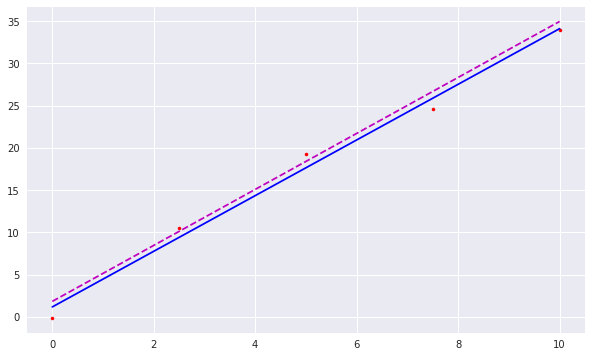

In [24]:
plt.figure(figsize=(10, 6))
yr = np.polyval(reg, x)
plt.plot(x, y, 'r.')
plt.plot(x, yr, 'b')
plt.plot(x, l1, 'm--');

## Neural Network for Classification

https://iamtrask.github.io/2015/07/12/basic-python-network/

### Sigmoid Function

https://en.wikipedia.org/wiki/Sigmoid_function

In [25]:
# sigmoid function
def sigmoid(x, deriv=False):
    if deriv == True:
        return sigmoid(x) * (1 - sigmoid(x))
    return 1 / (1 + np.exp(-x))

In [26]:
x = np.linspace(-10, 10)
y = sigmoid(x)
d = sigmoid(x, deriv=True)

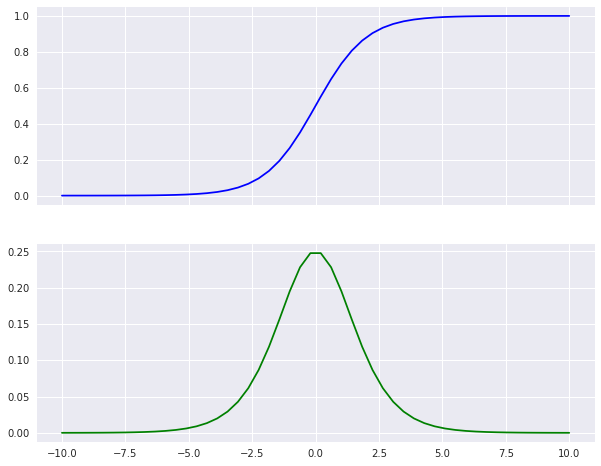

In [27]:
fig, ax = plt.subplots(2, sharex=True, figsize=(10, 8))
ax[0].plot(x, y, 'b')
ax[1].plot(x, d, 'g');

### The Data

In [28]:
# input dataset (features)
# layer 0
l0 = np.array([[0, 0, 1],
               [0, 1, 1],
               [1, 0, 1],
               [1, 1, 1]])

In [29]:
# output dataset (labels)          
y = np.array([[0,
               0,
               1,
               1]]).T

### Single Step

In [30]:
# initialize weights randomly with mean 0
np.random.seed(1)
weights = 2 * np.random.random((3, 1)) - 1
weights

array([[-0.16595599],
       [ 0.44064899],
       [-0.99977125]])

In [31]:
np.dot(l0, weights)

array([[-0.99977125],
       [-0.55912226],
       [-1.16572724],
       [-0.72507825]])

In [32]:
l1 = sigmoid(np.dot(l0, weights))
l1

array([[0.2689864 ],
       [0.36375058],
       [0.23762817],
       [0.3262757 ]])

In [33]:
e = y - l1
e

array([[-0.2689864 ],
       [-0.36375058],
       [ 0.76237183],
       [ 0.6737243 ]])

In [34]:
(e ** 2).mean()

0.3099458499092816

In [35]:
sigmoid(l1, True)

array([[0.24553187],
       [0.24190935],
       [0.24650375],
       [0.24346281]])

In [36]:
d = e * sigmoid(l1, True)
d

array([[-0.06604473],
       [-0.08799467],
       [ 0.18792752],
       [ 0.16402681]])

In [37]:
u = np.dot(l0.T, d)
u

array([[0.35195432],
       [0.07603214],
       [0.19791493]])

In [38]:
weights += u
weights

array([[ 0.18599833],
       [ 0.51668113],
       [-0.80185633]])

In [39]:
l1 = sigmoid(np.dot(l0, weights))
e = y - l1
(e ** 2).mean()

0.24425422705654065

### Multiple Steps

In [40]:
# initialize weights randomly with mean 0
np.random.seed(1)
weights = 2 * np.random.random((3, 1)) - 1
weights

array([[-0.16595599],
       [ 0.44064899],
       [-0.99977125]])

In [41]:
for _ in range(1001):
    # forward propagation
    # layer 1
    l1 = sigmoid(np.dot(l0, weights))

    # errors of layer 1
    e = y - l1
    if _ % 200 == 0:
        print('\nafter %d iterations' % _)
        print('layer 1:', l1.T)
        print('errors: ', e.T)
        print('MSE:    ', (e ** 2).mean())

    # multiply errors by the slope of the 
    # sigmoid at the values in l1
    d = e * sigmoid(l1, True)

    # update weights
    weights += np.dot(l0.T, d)


after 0 iterations
layer 1: [[0.2689864  0.36375058 0.23762817 0.3262757 ]]
errors:  [[-0.2689864  -0.36375058  0.76237183  0.6737243 ]]
MSE:     0.3099458499092816

after 200 iterations
layer 1: [[0.03581881 0.02486184 0.97910131 0.96983694]]
errors:  [[-0.03581881 -0.02486184  0.02089869  0.03016306]]
MSE:     0.0008119158612182872

after 400 iterations
layer 1: [[0.01812805 0.01228468 0.98963848 0.98469571]]
errors:  [[-0.01812805 -0.01228468  0.01036152  0.01530429]]
MSE:     0.00020528047087323443

after 600 iterations
layer 1: [[0.01210241 0.00814395 0.99312159 0.98977191]]
errors:  [[-0.01210241 -0.00814395  0.00687841  0.01022809]]
MSE:     9.117962675742859e-05

after 800 iterations
layer 1: [[0.00907573 0.00608783 0.99485433 0.99232527]]
errors:  [[-0.00907573 -0.00608783  0.00514567  0.00767473]]
MSE:     5.120249653700995e-05

after 1000 iterations
layer 1: [[0.00725744 0.00485959 0.99589051 0.9938605 ]]
errors:  [[-0.00725744 -0.00485959  0.00410949  0.0061395 ]]
MSE:    

In [42]:
weights

array([[10.41080251],
       [-0.40349007],
       [-4.91945304]])

In [43]:
np.where(l1 > 0.5, 1, 0)

array([[0],
       [0],
       [1],
       [1]])

In [44]:
np.where(y > 0.5, 1, 0)

array([[0],
       [0],
       [1],
       [1]])

<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="http://tpq.io" target="_blank">http://tpq.io</a> | <a href="http://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:training@tpq.io">training@tpq.io</a>